# Baseline-модели: Logistic Regression и Gradient Boosting

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

sys.path.append(str(Path('..').resolve()))
from src.preprocess import CreditPreprocessor

## 1. Загрузка и предобработка через модуль

In [2]:
data_path = Path('..') / 'data' / 'raw' / 'german_credit.csv'
df = pd.read_csv(data_path)

pre = CreditPreprocessor()
X, y = pre.fit_transform(df)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

feature_names = pre.get_feature_names()
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (800, 34) Test: (200, 34)


Вывод: данные подготовлены, разбиение стратифицировано, дисбаланс классов сохранен.

## 2. Logistic Regression

In [3]:
t0 = time.perf_counter()
logreg = LogisticRegression(max_iter=2000, class_weight='balanced')
logreg.fit(X_train, y_train)
time_logreg = time.perf_counter() - t0

p_logreg = logreg.predict_proba(X_test)[:, 1]
yhat_logreg = (p_logreg >= 0.5).astype(int)

print('Classification report (LogReg):')
print(classification_report(y_test, yhat_logreg, digits=4))
print('ROC-AUC:', roc_auc_score(y_test, p_logreg))
print('PR-AUC:', average_precision_score(y_test, p_logreg))

Classification report (LogReg):
              precision    recall  f1-score   support

           0     0.9009    0.7143    0.7968       140
           1     0.5506    0.8167    0.6577        60

    accuracy                         0.7450       200
   macro avg     0.7257    0.7655    0.7273       200
weighted avg     0.7958    0.7450    0.7551       200

ROC-AUC: 0.8186904761904762
PR-AUC: 0.6882624516409652


Вывод: логистическая регрессия дает сильный интерпретируемый baseline и хорошо калибруемые вероятности.

## 3. Gradient Boosting

In [4]:
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = neg / max(pos, 1)
sample_weight = np.where(y_train == 1, scale_pos_weight, 1.0)

t0 = time.perf_counter()
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train, sample_weight=sample_weight)
time_gb = time.perf_counter() - t0

p_gb = gb.predict_proba(X_test)[:, 1]
yhat_gb = (p_gb >= 0.5).astype(int)

print('Classification report (GB):')
print(classification_report(y_test, yhat_gb, digits=4))
print('ROC-AUC:', roc_auc_score(y_test, p_gb))
print('PR-AUC:', average_precision_score(y_test, p_gb))

Classification report (GB):
              precision    recall  f1-score   support

           0     0.8475    0.7143    0.7752       140
           1     0.5122    0.7000    0.5915        60

    accuracy                         0.7100       200
   macro avg     0.6798    0.7071    0.6834       200
weighted avg     0.7469    0.7100    0.7201       200

ROC-AUC: 0.7766666666666667
PR-AUC: 0.627446583005407


Вывод: бустинг обычно лучше улавливает нелинейные зависимости по сравнению с линейным baseline.

## 4. ROC и Precision-Recall кривые

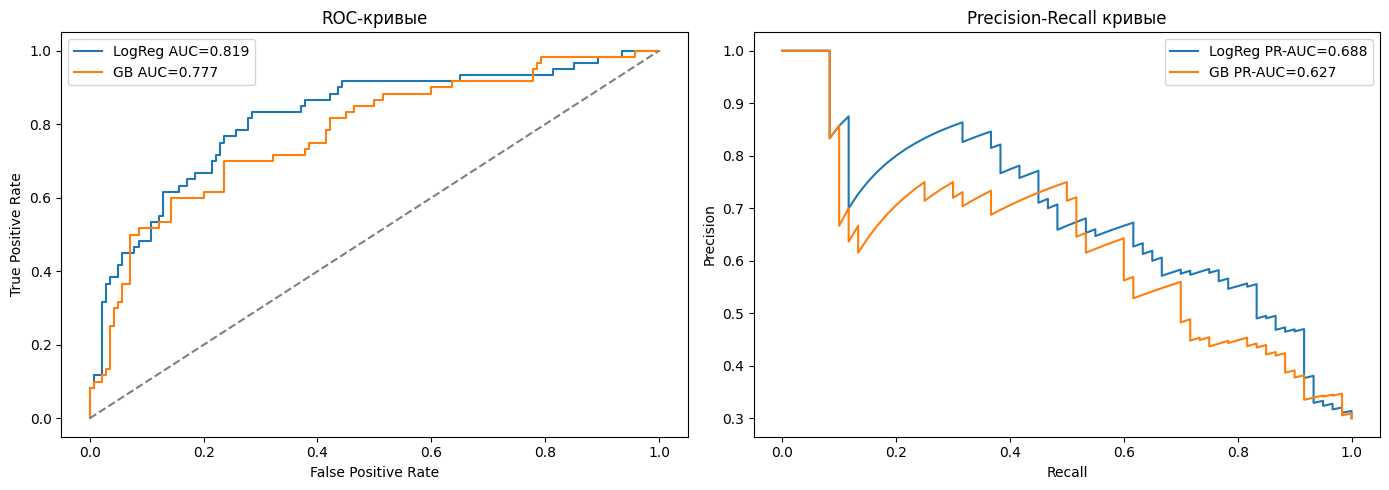

In [5]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, p_logreg)
fpr_gb, tpr_gb, _ = roc_curve(y_test, p_gb)

prec_lr, rec_lr, _ = precision_recall_curve(y_test, p_logreg)
prec_gb, rec_gb, _ = precision_recall_curve(y_test, p_gb)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr_lr, tpr_lr, label=f'LogReg AUC={roc_auc_score(y_test, p_logreg):.3f}')
axes[0].plot(fpr_gb, tpr_gb, label=f'GB AUC={roc_auc_score(y_test, p_gb):.3f}')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_title('ROC-кривые')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

axes[1].plot(rec_lr, prec_lr, label=f'LogReg PR-AUC={average_precision_score(y_test, p_logreg):.3f}')
axes[1].plot(rec_gb, prec_gb, label=f'GB PR-AUC={average_precision_score(y_test, p_gb):.3f}')
axes[1].set_title('Precision-Recall кривые')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.show()

Вывод: сопоставление ROC и PR-кривых показывает компромисс между полнотой и точностью для разных моделей.

## 5. Confusion matrix рядом

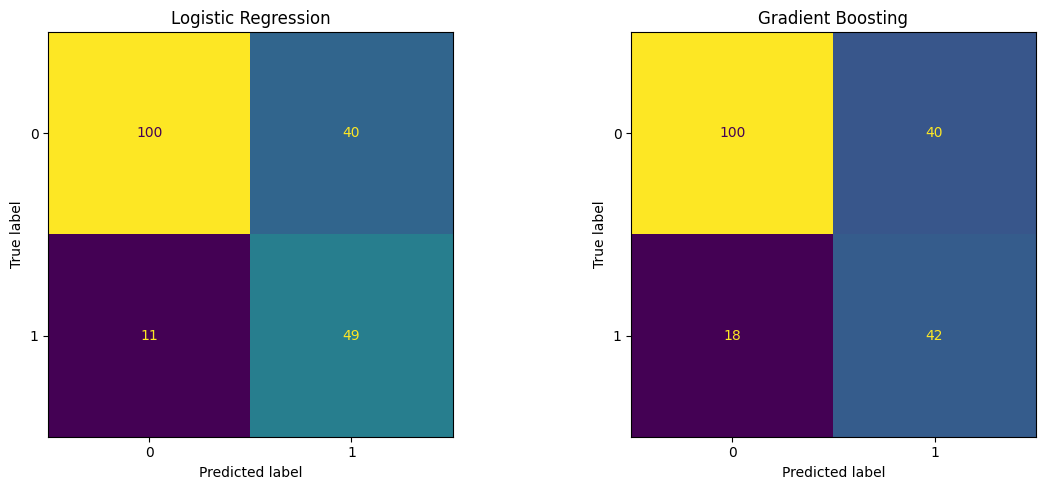

In [6]:
cm_lr = confusion_matrix(y_test, yhat_logreg)
cm_gb = confusion_matrix(y_test, yhat_gb)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_lr).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression')
ConfusionMatrixDisplay(cm_gb).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Gradient Boosting')
plt.tight_layout()
plt.show()

Вывод: матрицы ошибок показывают, какая модель лучше контролирует ложные одобрения и ложные отказы.

## 6. Feature importance (top-15) для GB

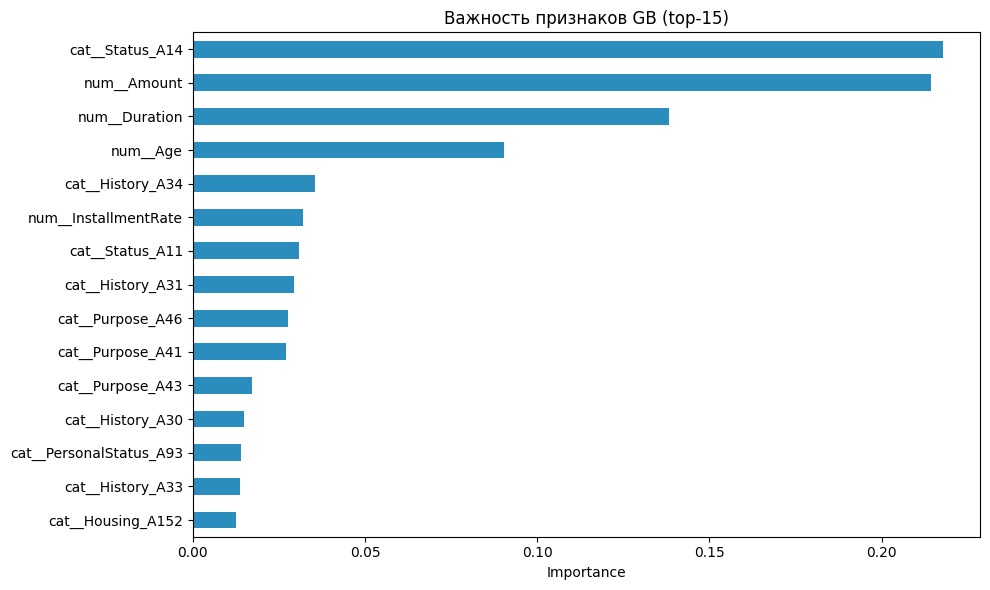

cat__Status_A14            0.217710
num__Amount                0.214452
num__Duration              0.138260
num__Age                   0.090433
cat__History_A34           0.035346
num__InstallmentRate       0.031903
cat__Status_A11            0.030968
cat__History_A31           0.029435
cat__Purpose_A46           0.027630
cat__Purpose_A41           0.027052
cat__Purpose_A43           0.017312
cat__History_A30           0.014825
cat__PersonalStatus_A93    0.014017
cat__History_A33           0.013592
cat__Housing_A152          0.012468
dtype: float64

In [7]:
fi = pd.Series(gb.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
fi.sort_values().plot(kind='barh', color='#2b8cbe')
plt.title('Важность признаков GB (top-15)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
fi

Вывод: наиболее значимые признаки отражают финансовую нагрузку и кредитную дисциплину клиента.

## 7. Таблица сравнения метрик

In [8]:
summary = pd.DataFrame([
    {
        'Модель': 'LogReg',
        'ROC-AUC': roc_auc_score(y_test, p_logreg),
        'PR-AUC': average_precision_score(y_test, p_logreg),
        'Время обучения, сек': time_logreg,
    },
    {
        'Модель': 'GradientBoosting',
        'ROC-AUC': roc_auc_score(y_test, p_gb),
        'PR-AUC': average_precision_score(y_test, p_gb),
        'Время обучения, сек': time_gb,
    },
])
summary

,Модель,ROC-AUC,PR-AUC,"Время обучения, сек"
0,LogReg,0.818690,0.688262,0.035255
1,GradientBoosting,0.776667,0.627447,0.312620
